In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
print("Libraries loaded")

Libraries loaded


In [2]:
# load data
df = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

# fix missing value
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)
df_test['Arrival Delay in Minutes'] = df_test['Arrival Delay in Minutes'].fillna(
    df_test['Arrival Delay in Minutes'].median()
)

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)

Train shape: (103904, 25)
Test shape: (25976, 25)


In [3]:
df.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [4]:
# identify categorical columns that need encoding
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

# create a label encoder
le = LabelEncoder()

# apply encoding to both train and test
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    df_test[col] = le.fit_transform(df_test[col])

print("Encoding done")
print(df[cat_cols].head())

Encoding done
   Gender  Customer Type  Type of Travel  Class  satisfaction
0       1              0               1      2             0
1       1              1               0      0             0
2       0              0               0      0             1
3       0              0               0      0             0
4       1              0               0      0             1


In [5]:
# drop columns that shouldn't be used for prediction
drop_cols = ['Unnamed: 0', 'id', 'satisfaction']

# features — everything except what we're predicting
X_train = df.drop(columns=drop_cols)
y_train = df['satisfaction']

X_test = df_test.drop(columns=drop_cols)
y_test = df_test['satisfaction']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (103904, 22)
y_train shape: (103904,)
X_test shape: (25976, 22)
y_test shape: (25976,)


In [6]:
# create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# train it
rf_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [7]:
# make predictions on test data
y_pred = rf_model.predict(X_test)

print("Predictions made:", len(y_pred))
print("Sample predictions:", y_pred[:10])

Predictions made: 25976
Sample predictions: [1 1 0 1 0 1 1 1 1 1]


In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"Baseline Accuracy: 56.60%")
print(f"Improvement over baseline: {(accuracy * 100) - 56.60:.2f}%")

Model Accuracy: 94.48%
Baseline Accuracy: 56.60%
Improvement over baseline: 37.88%


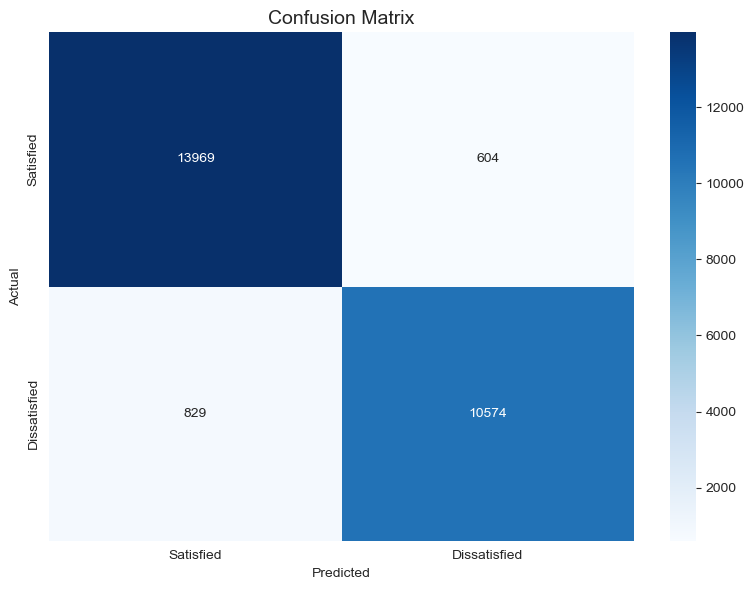

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Satisfied', 'Dissatisfied'],
            yticklabels=['Satisfied', 'Dissatisfied'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

In [10]:
print(classification_report(y_test, y_pred, 
      target_names=['Satisfied', 'Dissatisfied']))

              precision    recall  f1-score   support

   Satisfied       0.94      0.96      0.95     14573
Dissatisfied       0.95      0.93      0.94     11403

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



C:\Users\likhi\AppData\Local\Temp\ipykernel_28788\173700850.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values,


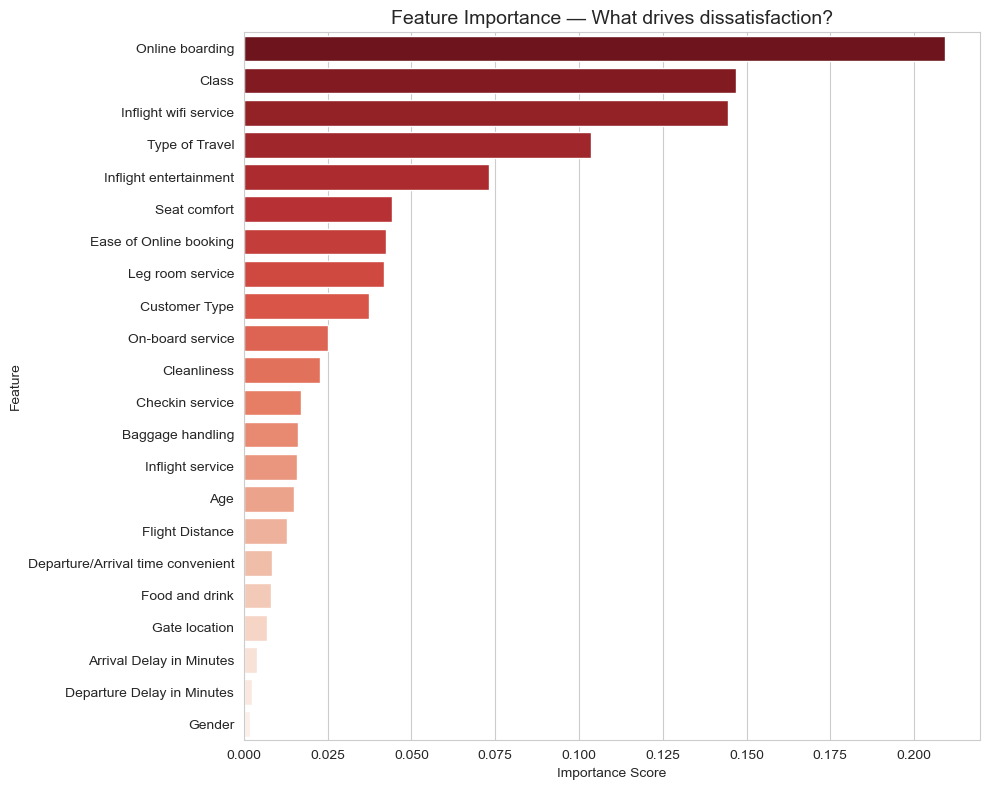

In [11]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance.values, 
            y=feature_importance.index, 
            palette='Reds_r')
plt.title('Feature Importance — What drives dissatisfaction?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

## BQ3 Findings — Predicting Dissatisfaction

**Model:** Random Forest Classifier (100 trees, max_depth=10)
**Accuracy:** 94.48% vs baseline of 56.60% — improvement of 37.88%

**Confusion Matrix:**
- Correctly identified 10,574 dissatisfied passengers
- Missed 829 dissatisfied passengers (Type 2 errors)
- 604 false alarms on satisfied passengers (Type 1 errors)

**Model Performance:**
- Dissatisfied precision: 0.95 — when model flags dissatisfied, it's right 95% of the time
- Dissatisfied recall: 0.93 — model catches 93% of all actually dissatisfied passengers

**Top 5 features driving dissatisfaction:**
1. Online boarding
2. Class
3. Inflight wifi service
4. Type of Travel
5. Inflight entertainment

**Key insight:** The ML model confirms Day 3 correlation findings —
online boarding and inflight entertainment are the top drivers.
3 of the top 5 features are technology-related, suggesting the airline's
biggest problem is its digital experience, not physical comfort.

In [12]:
feature_imp_df = pd.DataFrame({
    'Feature': feature_importance.index,
    'Importance': feature_importance.values
}).head(10)  # top 10 only

feature_imp_df.to_csv('../data/feature_importance.csv', index=False)
print(feature_imp_df)

                  Feature  Importance
0         Online boarding    0.209226
1                   Class    0.146898
2   Inflight wifi service    0.144621
3          Type of Travel    0.103581
4  Inflight entertainment    0.073038
5            Seat comfort    0.044209
6  Ease of Online booking    0.042523
7        Leg room service    0.041926
8           Customer Type    0.037437
9        On-board service    0.025148
